In [1]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,END
from langchain_community.document_loaders import TextLoader, DirectoryLoader


c:\Users\mendh\Langchain-Langgraph\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
loader = DirectoryLoader(r"C:\Users\mendh\Langchain-Langgraph\0-Dataingestion-parsing\data\text_files",loader_cls=TextLoader)
docs= loader.load()

In [3]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks = splitter.split_documents(docs)
vectorstore = FAISS.from_documents(chunks,embedding=embeddings)
retriever = vectorstore.as_retriever()

C:\Users\mendh\AppData\Local\Temp\ipykernel_13084\1293108103.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
import os
from langchain_classic.chat_models import init_chat_model
from dotenv import load_dotenv
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = init_chat_model(model_provider="groq",model = "llama-3.1-8b-instant")

In [5]:
class RAGState(BaseModel):
    question: str
    sub_questions: list[str]=[]
    retrieved_docs: List[Document] = []
    answer: str = ""

In [6]:
def plan_query(state:RAGState):
    prompt = f"Break the following complex question into 2-3 sub-questions : \n\n {state.question} sub-questions: "
    result = llm.invoke(prompt).content
    subqs = [line.strip("- ") for line in result.split("\n") if line.strip()]

    return state.model_copy(update={"sub_questions":subqs})

In [7]:
def generate_answer(state: RAGState):
    context = f"\n\n".join([doc.page_content for doc in state.retrieved_docs])

    prompt = f""" Use the contect below to answer the questions:

    Question: {state.question}

Context: {context}

Now Synthesize a well-reasoned final answer
"""
    
    result = llm.invoke(prompt).content.strip()

    return state.model_copy(update = {"answer":result})

def retrieve_(state: RAGState):
    all_docs= []
    for sub in state.sub_questions:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    
    return state.model_copy(update = {"retriever_docs":all_docs})

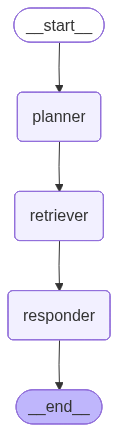

In [8]:
builder = StateGraph(RAGState)
builder.add_node("planner",plan_query)
builder.add_node("retriever",retrieve_)
builder.add_node("responder",generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner","retriever")
builder.add_edge("retriever","responder")
builder.add_edge("responder",END)

graph = builder.compile()
graph

In [9]:
query = "Explain Machine learning and what are their types"

state = RAGState(question=query)
final = graph.invoke(state)

print("sub questions:\n", final["sub_questions"])
print("Final answer:\n", final["answer"])


sub questions:
 ["Here's a breakdown of the complex question into 3 sub-questions:", '1. **What is Machine Learning?**', 'This sub-question can be answered by explaining the definition, concept, and purpose of machine learning. It can also include the types of problems that machine learning can solve and the benefits of using machine learning.', '2. **How do Machine Learning Algorithms Work?**', 'This sub-question can delve into the inner workings of machine learning algorithms, including how they learn from data, make predictions, and improve their performance over time.', '3. **What are the Main Types of Machine Learning?**', 'This sub-question can be further broken down into the following sub-sub-questions:', 'a. **Supervised Learning**: What is supervised learning, and how do supervised learning algorithms work?', 'b. **Unsupervised Learning**: What is unsupervised learning, and how do unsupervised learning algorithms work?', 'c. **Reinforcement Learning**: What is reinforcement le

In [10]:
from langchain.tools import tool
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun
from langchain_community.utilities.wikipedia import WikipediaAPIWrapper

api_wrapper = WikipediaAPIWrapper()
wiki_engine = WikipediaQueryRun(api_wrapper=api_wrapper)


from langchain_core.documents import Document

def wiki_search(state: RAGState):
    """Node to retrieve information from wikipedia"""
    all_docs = []
    
    for sub in state.sub_questions:
        print(f"Using Wiki tool: query is: {sub}")
        result_text = wiki_engine.run(sub)
        
        # Wrap the string in a Document object to match the State schema
        doc = Document(page_content=result_text, metadata={"source": "wikipedia", "query": sub})
        all_docs.append(doc)
    
    return {"retrieved_docs": all_docs}




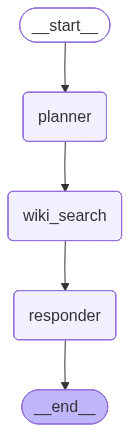

In [11]:
builder = StateGraph(RAGState)
builder.add_node("planner",plan_query)
builder.add_node("wiki_search",wiki_search)
builder.add_node("responder",generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner","wiki_search")
builder.add_edge("wiki_search","responder")
builder.add_edge("responder",END)

graph = builder.compile()
graph

In [12]:
query = "What are agent loops work and what are the challenges in diffusion video generation?"


state = RAGState(question=query)
final = graph.invoke(state)

print("sub questions:\n", final["sub_questions"])
print("Final answer:\n", final["answer"])


Using Wiki tool: query is: Here are the complex question broken down into 3 sub-questions:
Using Wiki tool: query is: 1. **What are agent loops in the context of diffusion video generation?**
Using Wiki tool: query is: This sub-question seeks to understand the concept of agent loops, including their role and functionality within the framework of diffusion video generation.
Using Wiki tool: query is: 2. **How do agent loops influence the generation of realistic video content in diffusion models?**
Using Wiki tool: query is: This sub-question delves into the specifics of how agent loops contribute to the creation of realistic video content, including their impact on video quality, coherence, and overall fidelity.
Using Wiki tool: query is: 3. **What are some of the key challenges associated with integrating agent loops into diffusion video generation models?**
Using Wiki tool: query is: This sub-question highlights the difficulties and limitations that researchers and developers face whe

In [13]:
query = "what are the LLM evulation techniques?"

state = RAGState(question=query)
final = graph.invoke(state)

print("Reasoning Steps:\n", final["sub_questions"])
print("Final answer:\n", final["answer"])


Using Wiki tool: query is: Here's a breakdown of the complex question into 3 sub-questions:
Using Wiki tool: query is: 1. **What are the key evaluation metrics used to assess Large Language Models (LLMs)?**
Using Wiki tool: query is: This sub-question focuses on the specific metrics that are commonly used to evaluate LLMs, such as accuracy, perplexity, ROUGE score, etc.
Using Wiki tool: query is: 2. **What are the different types of evaluation techniques used for LLMs, such as human evaluation, automated evaluation, and hybrid evaluation?**
Using Wiki tool: query is: This sub-question explores the various approaches to evaluating LLMs, including the use of human evaluators, automated tools, and combinations of both.
Using Wiki tool: query is: 3. **How do LLM evaluation techniques account for factors such as bias, fairness, and explainability, and what are the challenges associated with these evaluations?**
Using Wiki tool: query is: This sub-question delves into the complexities of eva

In [14]:
final["sub_questions"]

["Here's a breakdown of the complex question into 3 sub-questions:",
 '1. **What are the key evaluation metrics used to assess Large Language Models (LLMs)?**',
 'This sub-question focuses on the specific metrics that are commonly used to evaluate LLMs, such as accuracy, perplexity, ROUGE score, etc.',
 '2. **What are the different types of evaluation techniques used for LLMs, such as human evaluation, automated evaluation, and hybrid evaluation?**',
 'This sub-question explores the various approaches to evaluating LLMs, including the use of human evaluators, automated tools, and combinations of both.',
 '3. **How do LLM evaluation techniques account for factors such as bias, fairness, and explainability, and what are the challenges associated with these evaluations?**',
 'This sub-question delves into the complexities of evaluating LLMs in terms of bias, fairness, and explainability, and the challenges that arise when attempting to assess these aspects.']